<a href="https://colab.research.google.com/github/kuppanagariadithya-boop/Sentiment-Analysis/blob/main/Welcome_to_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORT NECESSARY LIBARIES

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

SET VISUALIZATION STYLE

In [18]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8,5)

LOAD DATASET

In [19]:
df = pd.read_csv("Twitter_Data.csv")

df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


BASIC DATASET OVERVIEW

In [20]:
df.info()

df.shape

df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162980 entries, 0 to 162979
Data columns (total 2 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   clean_text  162976 non-null  object 
 1   category    162973 non-null  float64
dtypes: float64(1), object(1)
memory usage: 2.5+ MB


Index(['clean_text', 'category'], dtype='object')

CHECK MISSING VALUES

In [21]:
df.isnull().sum()

,0
clean_text,4
category,7


DATA CLEANING

In [22]:
df.dropna(inplace=True)

df.head()

,clean_text,category
0,when modi promised “minimum government maximum...,-1.0
1,talk all the nonsense and continue all the dra...,0.0
2,what did just say vote for modi welcome bjp t...,1.0
3,asking his supporters prefix chowkidar their n...,1.0
4,answer who among these the most powerful world...,1.0


SENTIMENT DISTRIBUTION

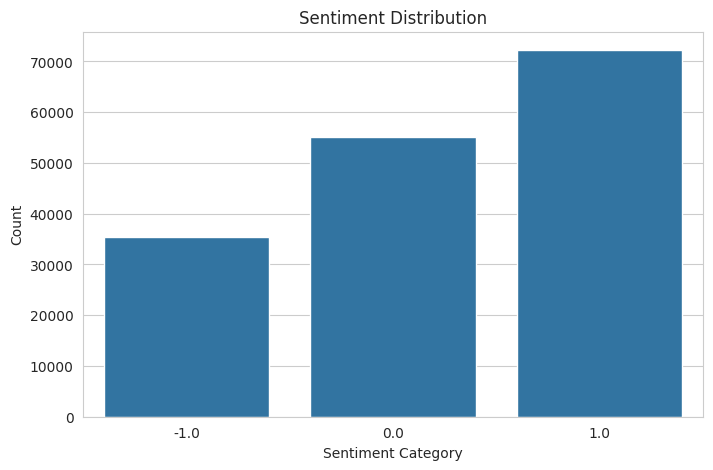

In [23]:
sns.countplot(x="category", data=df)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment Category")
plt.ylabel("Count")

plt.show()

CONVERT TEXT DATA TO NUMERICAL DATA

In [24]:
vectorizer = CountVectorizer()

X = vectorizer.fit_transform(df["clean_text"])
y = df["category"]

SPLIT TRAINING AND TESTING DATA

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

TRAIN AND SENTIMENT MODEL

In [26]:
model = MultinomialNB()

model.fit(X_train, y_train)

MultinomialNB()

PREDICT SENTIMENT

In [27]:
y_pred = model.predict(X_test)

EVALUATE THE MODEL

In [28]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Accuracy: 0.7482665521261582
              precision    recall  f1-score   support

        -1.0       0.74      0.63      0.68      7152
         0.0       0.91      0.61      0.73     11067
         1.0       0.69      0.91      0.78     14375

    accuracy                           0.75     32594
   macro avg       0.78      0.72      0.73     32594
weighted avg       0.77      0.75      0.74     32594



TEST CUSTOM TWEET

In [29]:
tweet = ["India economy is growing very fast"]

tweet_vector = vectorizer.transform(tweet)

prediction = model.predict(tweet_vector)

print("Predicted Sentiment:", prediction[0])

Predicted Sentiment: 1.0


SAVE CLEAN DATASET

In [30]:
df.to_csv("cleaned_twitter_sentiment_data.csv", index=False)